# Task 4: Object Detection and Tracking

## Description
This project implements real-time object detection and tracking using YOLOv8 and OpenCV. A pre-trained YOLO model is used to identify objects such as people, bicycles, and vehicles in a video. Detected objects are highlighted with bounding boxes, labels, and tracking IDs to monitor their movement across frames.

## Features
- Object detection using YOLOv8
- Real-time video processing
- Bounding box visualization
- Object tracking across frames
- Output video generation

## Technologies Used
- Python
- OpenCV
- YOLOv8 (Ultralytics)
- Google Colab

## Working
1. Load a video file.
2. Process each frame using YOLOv8.
3. Detect and classify objects.
4. Track detected objects across frames.
5. Draw bounding boxes and labels.
6. Save the processed output video.

## Output
A processed video showing detected objects with labels and tracking information.

In [17]:
!pip install ultralytics opencv-python

In [18]:
import cv2
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

In [19]:
!wget https://github.com/intel-iot-devkit/sample-videos/raw/master/person-bicycle-car-detection.mp4

--2026-06-03 12:41:15--  https://github.com/intel-iot-devkit/sample-videos/raw/master/person-bicycle-car-detection.mp4
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/intel-iot-devkit/sample-videos/master/person-bicycle-car-detection.mp4 [following]
--2026-06-03 12:41:16--  https://raw.githubusercontent.com/intel-iot-devkit/sample-videos/master/person-bicycle-car-detection.mp4
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6031199 (5.8M) [application/octet-stream]
Saving to: ‘person-bicycle-car-detection.mp4.1’

person-bicycle-car- 100%[===================>]   5.75M  --.-KB/s    in 0.08s   

20

In [20]:
model = YOLO("yolov8n.pt")

In [21]:
cap = cv2.VideoCapture("person-bicycle-car-detection.mp4")

In [22]:
print(cap.isOpened())

True


In [23]:
ret, frame = cap.read()
print(ret)

True


In [24]:
results = model(frame)


0: 384x640 (no detections), 238.0ms
Speed: 7.7ms preprocess, 238.0ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)


In [25]:
annotated_frame = results[0].plot()

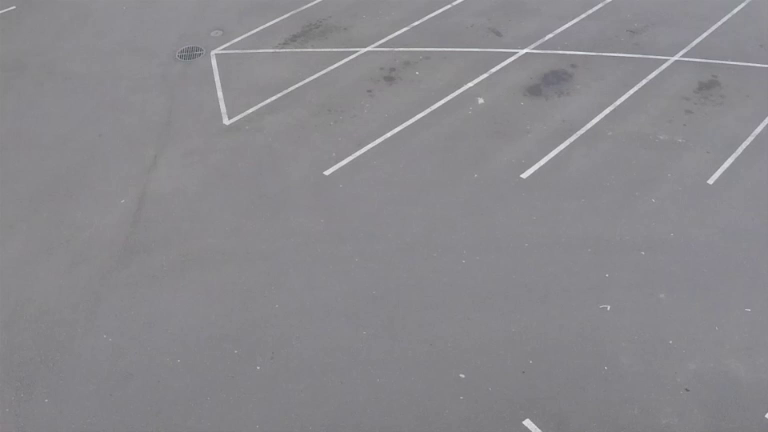

In [26]:
cv2_imshow(annotated_frame)

In [27]:
cap.release()
cap = cv2.VideoCapture("person-bicycle-car-detection.mp4")

In [28]:
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')

out = cv2.VideoWriter(
    'output.mp4',
    fourcc,
    20.0,
    (width, height)
)

In [29]:
while True:
    ret, frame = cap.read()

    if not ret:
        break

    results = model.track(frame, persist=True)

    annotated_frame = results[0].plot()

    out.write(annotated_frame)


0: 384x640 (no detections), 217.1ms
Speed: 6.7ms preprocess, 217.1ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 212.5ms
Speed: 5.7ms preprocess, 212.5ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 140.6ms
Speed: 5.7ms preprocess, 140.6ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 156.1ms
Speed: 4.9ms preprocess, 156.1ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 202.0ms
Speed: 4.0ms preprocess, 202.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 208.6ms
Speed: 6.6ms preprocess, 208.6ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 143.0ms
Speed: 3.6ms preprocess, 143.0ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 135.0ms
Speed: 2.7ms prepr

In [30]:
cap.release()
out.release()

In [31]:
import os
print(os.listdir())

['.config', 'yolov8n.pt', 'person-bicycle-car-detection.mp4.1', 'output.mp4', 'person-bicycle-car-detection.mp4', 'sample_data']


In [32]:
from google.colab import files
files.download("output.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>